# 04 · Differential expression analysis (DEA)
**Input:** `data/processed/adata_annotated.h5ad`
**Output:** `data/processed/dea_results.csv`

Wilcoxon rank-sum test comparing tumor (HCC2) vs normal-adjacent (HCC1) tissue.
Threshold: padj < 0.05 and |log2FC| > 1.


In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
adata = sc.read("../data/processed/adata_annotated.h5ad")
print(adata)

AnnData object with n_obs × n_vars = 2795 × 33694
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'leiden_res_0.30', 'leiden_res_0.50', 'leiden_res_1.00', 'leiden_res_2.00', 'celltypist_coarse', 'celltypist_fine', 'sctype_cell_type', 'SingleR_HPCA', 'manual_celltype'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'celltypist_coarse_colors', 'celltypist_fin

## Wilcoxon rank-sum test (tumor vs normal)

In [8]:
sc.tl.rank_genes_groups(adata, groupby="sample", method="wilcoxon")
de_results = sc.get.rank_genes_groups_df(adata, group="tumor (HCC2)")

sig = de_results[
    (de_results["pvals_adj"] < 0.05) &
    (de_results["logfoldchanges"].abs() > 1)
].copy()
sig.columns = ["gene","scores", "log2FC","pvalue","adj_pvalue"]
sig["regulation"] = (sig["log2FC"] > 0).map({True:"up", False:"down"})

print(f"Total DEGs    : {len(sig)}")
print(f"Upregulated   : {(sig.regulation=='up').sum()}")
print(f"Downregulated : {(sig.regulation=='down').sum()}")
sig.head(10)

Total DEGs    : 1385
Upregulated   : 335
Downregulated : 1050


,gene,scores,log2FC,pvalue,adj_pvalue,regulation
0,RPS26,26.308933,1.991955,1.515576e-152,7.295115e-149,up
1,XIST,23.464739,31.180847,9.349445e-122,2.625168e-118,up
2,MALAT1,20.834894,1.089554,2.089721e-96,3.200503e-93,up
3,CREM,19.406971,2.918553,6.738461e-84,7.829163e-81,up
4,JUND,18.446568,1.322786,5.556331e-76,5.349000e-73,up
6,RP11-138A9.2,16.519718,3.155438,2.646311e-61,1.621178e-58,up
7,HLA-C,16.483912,1.089220,4.788466e-61,2.881117e-58,up
8,ZFP36L2,16.010973,2.108820,1.071225e-57,5.552903e-55,up
9,BTG1,15.975739,1.349612,1.886050e-57,9.484859e-55,up
10,SRSF7,15.574635,1.745543,1.082697e-54,5.211486e-52,up


In [9]:
sig.tail(10)

,gene,scores,log2FC,pvalue,adj_pvalue,regulation
33684,TMSB10,-23.827902,-1.510665,1.716509e-125,5.257822e-122,down
33685,GAPDH,-23.923506,-1.877306,1.744108e-126,5.876599e-123,down
33686,LGALS1,-25.626949,-3.678944,7.641677e-145,2.860874e-141,down
33687,SPP1,-25.883593,-9.936964,1.019111e-147,4.292242e-144,down
33688,APOC1,-27.403347,-7.994852,2.501837e-165,1.404948e-161,down
33689,APOE,-28.140615,-7.409281,3.121773e-174,2.103700e-170,down
33690,SERPINA1,-31.061487,-5.559215,7.982380e-212,6.723958e-208,down
33691,FTL,-33.603001,-4.258161,1.516437e-247,1.703161e-243,down
33692,ALB,-36.982944,-33.181702,2.153163e-299,3.627433e-295,down
33693,APOA2,-37.779270,-33.587166,0.000000e+00,0.000000e+00,down


## Volcano plot

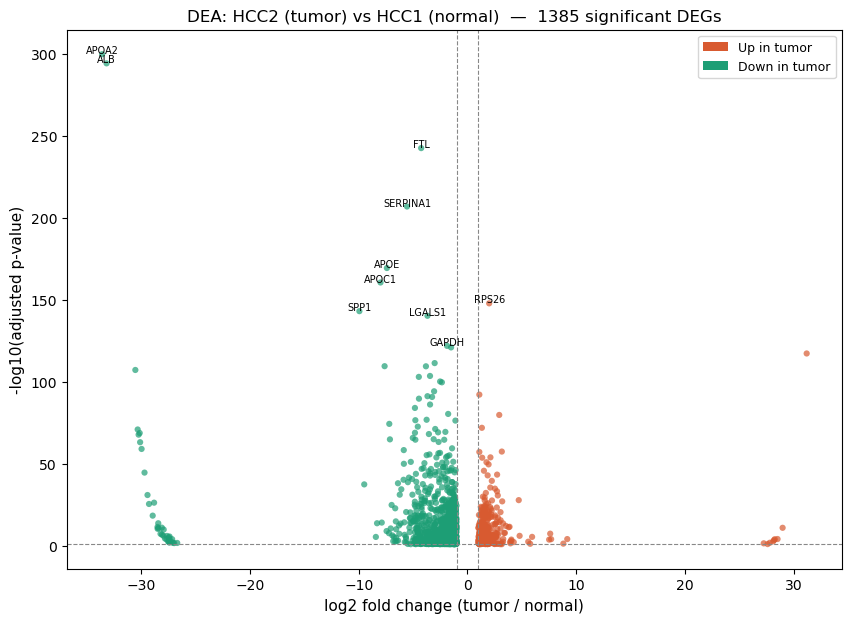

In [10]:
fig, ax = plt.subplots(figsize=(10, 7))
colors = sig["regulation"].map({"up":"#D85A30","down":"#1D9E75"})
ax.scatter(sig["log2FC"], -np.log10(sig["adj_pvalue"]+1e-300),
           c=colors, alpha=0.7, s=20, linewidths=0)
ax.axvline(1,  color="#888", lw=0.8, ls="--")
ax.axvline(-1, color="#888", lw=0.8, ls="--")
ax.axhline(-np.log10(0.05), color="#888", lw=0.8, ls="--")

# Label top 10 by adjusted p-value
top10 = sig.nsmallest(10, "adj_pvalue")
for _, r in top10.iterrows():
    ax.text(r["log2FC"], -np.log10(r["adj_pvalue"]+1e-300)+0.3,
            r["gene"], fontsize=7, ha="center")

ax.set_xlabel("log2 fold change (tumor / normal)", fontsize=11)
ax.set_ylabel("-log10(adjusted p-value)", fontsize=11)
ax.set_title(f"DEA: HCC2 (tumor) vs HCC1 (normal)  —  {len(sig)} significant DEGs",
             fontsize=12)
import matplotlib.patches as mp
ax.legend(handles=[mp.Patch(facecolor="#D85A30",label="Up in tumor"),
                   mp.Patch(facecolor="#1D9E75",label="Down in tumor")], fontsize=9)
fig.savefig("../results/figures/volcano_plot.png", dpi=200, bbox_inches="tight")
plt.show()

## Export DEA results

In [11]:
out = Path("../data/processed/dea_results.csv")
sig[["gene","log2FC","adj_pvalue","regulation"]].to_csv(out, index=False)
print(f"Saved: {out}  ({len(sig)} DEGs)")
print("Top 5 upregulated:")
print(sig[sig.regulation=="up"].nlargest(5,"log2FC")[["gene","log2FC","adj_pvalue"]])
print("\nTop 5 downregulated:")
print(sig[sig.regulation=="down"].nsmallest(5,"log2FC")[["gene","log2FC","adj_pvalue"]])

Saved: ..\data\processed\dea_results.csv  (1385 DEGs)
Top 5 upregulated:
        gene     log2FC     adj_pvalue
1       XIST  31.180847  2.625168e-118
126    OLFM4  28.968952   4.820013e-12
269    ADH1C  28.503433   3.367689e-05
280     TFF2  28.247526   4.383444e-05
310  CEACAM6  28.181561   1.653879e-04

Top 5 downregulated:
         gene     log2FC     adj_pvalue
33693   APOA2 -33.587166   0.000000e+00
33692     ALB -33.181702  3.627433e-295
33680  RPS4Y1 -30.532921  2.993306e-108
33662   FABP1 -30.319868   5.665009e-72
33656    AHSG -30.232588   7.987003e-69
